In [ ]:
%pip install matplotlib seaborn pandas numpy


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


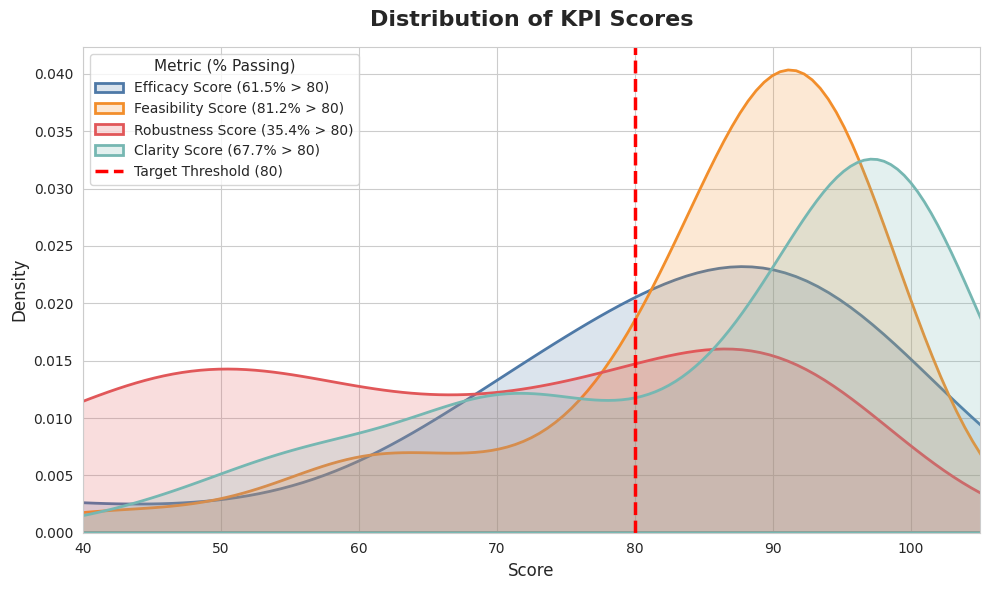

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

filename = "sorted_summary_report_v5_final.csv"
df = pd.read_csv(filename)

kpi_cols = ['T15_Efficacy_Score', 'T15_Feasibility_Score', 'T14_Robustness_Score', 'T14_Clarity_Score']

df_clean = df.copy()
for col in kpi_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
df_clean = df_clean.dropna(subset=kpi_cols, how='all')

# 2. based line %
stats = {col: (df_clean[col] >= 80).mean() * 100 for col in kpi_cols}

# Create Graph
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
colors = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2']

for i, col in enumerate(kpi_cols):
    label_name = col.replace('T15_', '').replace('T14_', '').replace('_', ' ')

    # KDE
    sns.kdeplot(df_clean[col], fill=True,
                label=f"{label_name} ({stats[col]:.1f}% > 80)",
                color=colors[i], alpha=0.2, linewidth=2)

plt.axvline(x=80, color='red', linestyle='--', linewidth=2.5, label='Target Threshold (80)')

plt.title('Distribution of KPI Scores', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(40, 105)
plt.legend(title='Metric (% Passing)', title_fontsize='11', loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

Data ready: 95 rows


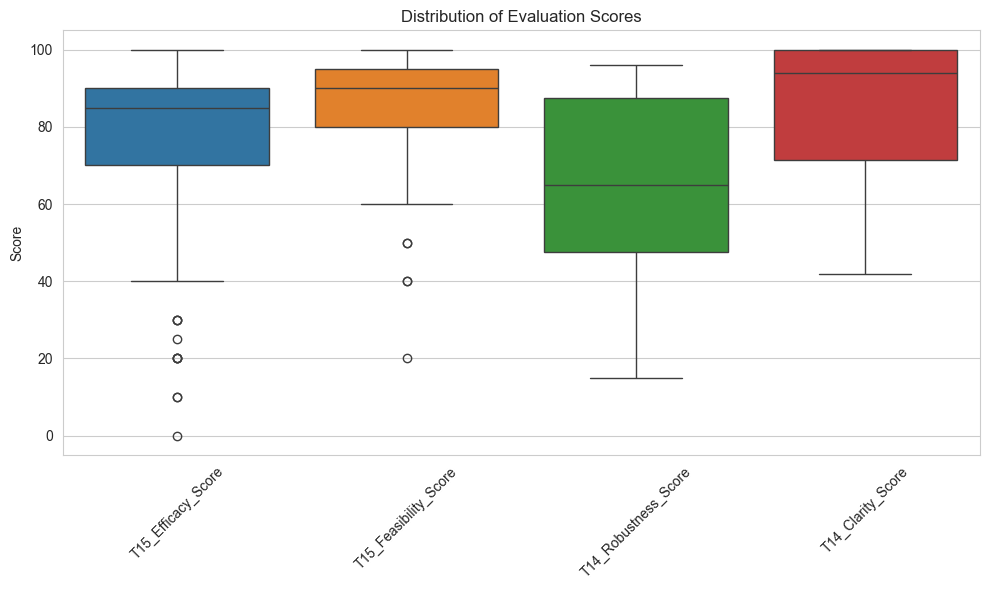

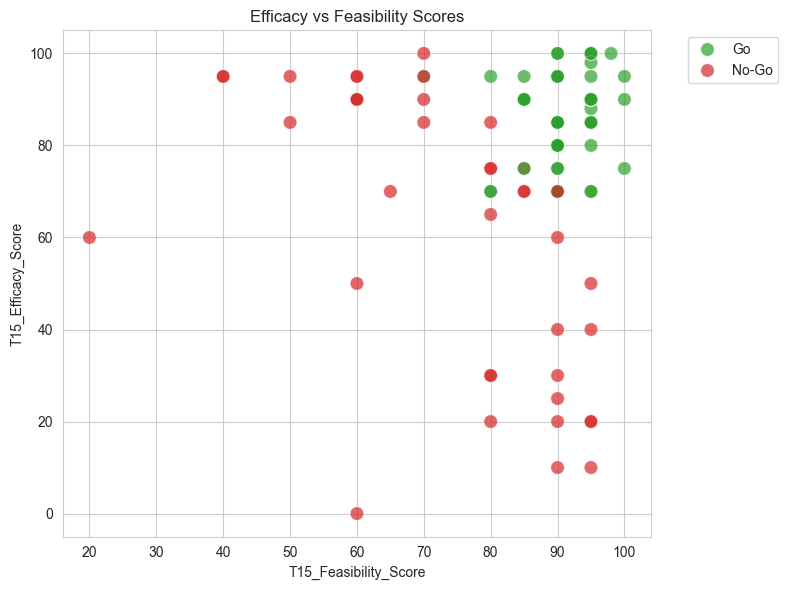

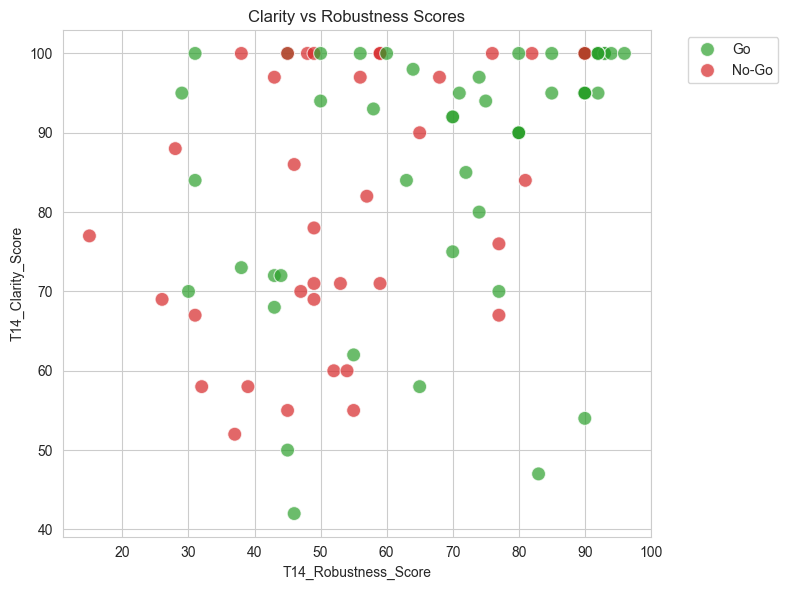

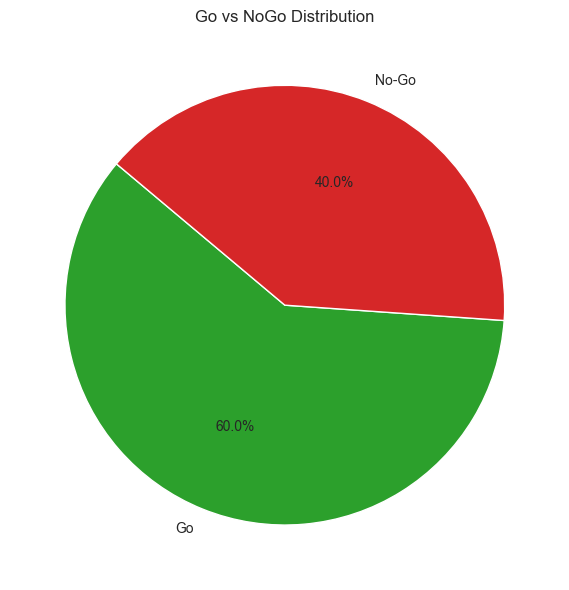

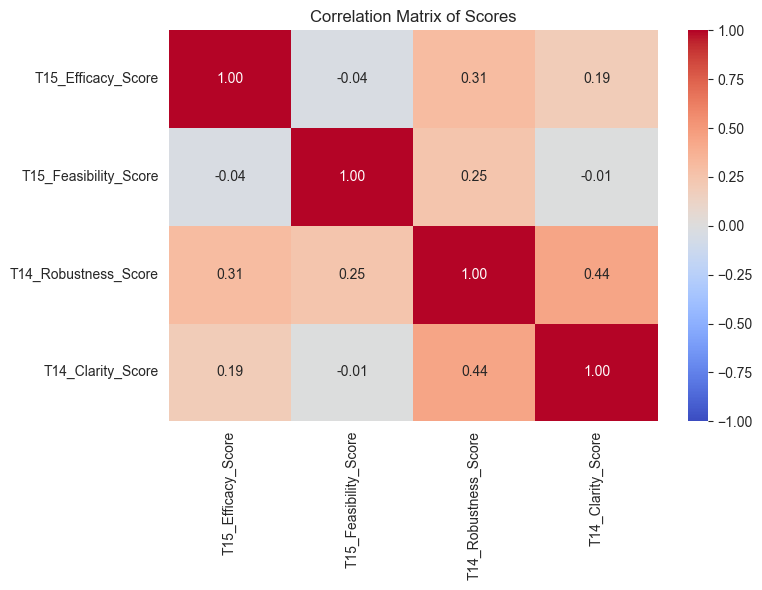

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

filename = "sorted_summary_report_v5_final.csv"
df = pd.read_csv(filename)

# convert Folder_Path and T15_Go_NoGo to String and replace NaN to empty
df['Folder_Path'] = df['Folder_Path'].astype(str).fillna('')
df['T15_Go_NoGo'] = df['T15_Go_NoGo'].astype(str).fillna('')

# filter:
# 1. Folder_Path to empty
# 2. 'AVERAGE'
# 3. 'nan'
df_clean = df[df['Folder_Path'].str.strip() != '']
df_clean = df_clean[~df_clean['Folder_Path'].str.contains('AVERAGE', case=False)]
df_clean = df_clean[df_clean['Folder_Path'] != 'nan']

# Column
numeric_cols = ['T15_Efficacy_Score', 'T15_Feasibility_Score', 'T14_Robustness_Score', 'T14_Clarity_Score']

# convert score column to number or NaN
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# filter row NaN in the first column
df_clean = df_clean.dropna(subset=numeric_cols)

# Color Palette Go and No-Go
unique_statuses = df_clean['T15_Go_NoGo'].unique()
palette = {}
for status in unique_statuses:
    if 'go' in status.lower() and 'no' not in status.lower():
        palette[status] = '#2ca02c' # green
    else:
        palette[status] = '#d62728' # red

print(f"Data ready: {df_clean.shape[0]} rows")

# ---------------------------------------------------------
# 2. Visualization

# Style graph
sns.set_style("whitegrid")

# Graph 1: Distribution of Scores (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean[numeric_cols])
plt.title('Distribution of Evaluation Scores')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Graph 2: Efficacy vs Feasibility (Scatter Plot)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clean,
    x='T15_Feasibility_Score',
    y='T15_Efficacy_Score',
    hue='T15_Go_NoGo',
    palette=palette,
    s=100,
    alpha=0.7
)
plt.title('Efficacy vs Feasibility Scores')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # move Legend
plt.tight_layout()
plt.show()

# Graph 3: Clarity vs Robustness (Scatter Plot)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clean,
    x='T14_Robustness_Score',
    y='T14_Clarity_Score',
    hue='T15_Go_NoGo',
    palette=palette,
    s=100,
    alpha=0.7
)
plt.title('Clarity vs Robustness Scores')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Graph 4: Go vs NoGo Count (Pie Chart)
plt.figure(figsize=(6, 6))
go_nogo_counts = df_clean['T15_Go_NoGo'].value_counts()
colors = [palette.get(x, 'gray') for x in go_nogo_counts.index]
plt.pie(
    go_nogo_counts,
    labels=go_nogo_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)
plt.title('Go vs NoGo Distribution')
plt.tight_layout()
plt.show()

# Graph 5: Correlation Matrix (Heatmap)
plt.figure(figsize=(8, 6))
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix of Scores')
plt.tight_layout()
plt.show()